<a href="https://colab.research.google.com/github/Khanbir/Data_analitycs/blob/main/DZ_16_%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D1%94_%D0%B7%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_%D0%9F%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D1%83%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D0%BE%D1%80%D0%B5%D0%BD%D0%B4%D0%BD%D0%BE%D1%97_%D0%BF%D0%BB%D0%B0%D1%82%D0%B8_%D0%B7%D0%B0_%D0%B6%D0%B8%D1%82%D0%BB%D0%BE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
df = pd.read_csv ('/content/drive/MyDrive/DATA-ANALITICS_ Pylieva/House_Rent_Dataset.csv')
print (df.head())
print("\nЗагальна інформація про датасет:")
print(df.info())

    Posted On  BHK   Rent  Size            Floor    Area Type  \
0  2022-05-18    2  10000  1100  Ground out of 2   Super Area   
1  2022-05-13    2  20000   800       1 out of 3   Super Area   
2  2022-05-16    2  17000  1000       1 out of 3   Super Area   
3  2022-07-04    2  10000   800       1 out of 2   Super Area   
4  2022-05-09    2   7500   850       1 out of 2  Carpet Area   

              Area Locality     City Furnishing Status  Tenant Preferred  \
0                    Bandel  Kolkata       Unfurnished  Bachelors/Family   
1  Phool Bagan, Kankurgachi  Kolkata    Semi-Furnished  Bachelors/Family   
2   Salt Lake City Sector 2  Kolkata    Semi-Furnished  Bachelors/Family   
3               Dumdum Park  Kolkata       Unfurnished  Bachelors/Family   
4             South Dum Dum  Kolkata       Unfurnished         Bachelors   

   Bathroom Point of Contact  
0         2    Contact Owner  
1         1    Contact Owner  
2         1    Contact Owner  
3         1    Contact Owner

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [4]:
# Перевірка на пропущені значення
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

print("Пропущені значення та їх відсоток:")
print(pd.DataFrame({'Кількість': missing_values, 'Відсоток': missing_percentage}))
# Базова статистика для числових змінних
print("\nБазова статистика для числових змінних:")
print(df.describe())

Пропущені значення та їх відсоток:
                   Кількість  Відсоток
Posted On                  0       0.0
BHK                        0       0.0
Rent                       0       0.0
Size                       0       0.0
Floor                      0       0.0
Area Type                  0       0.0
Area Locality              0       0.0
City                       0       0.0
Furnishing Status          0       0.0
Tenant Preferred           0       0.0
Bathroom                   0       0.0
Point of Contact           0       0.0

Базова статистика для числових змінних:
               BHK          Rent         Size     Bathroom
count  4746.000000  4.746000e+03  4746.000000  4746.000000
mean      2.083860  3.499345e+04   967.490729     1.965866
std       0.832256  7.810641e+04   634.202328     0.884532
min       1.000000  1.200000e+03    10.000000     1.000000
25%       2.000000  1.000000e+04   550.000000     1.000000
50%       2.000000  1.600000e+04   850.000000     2.000000
75% 

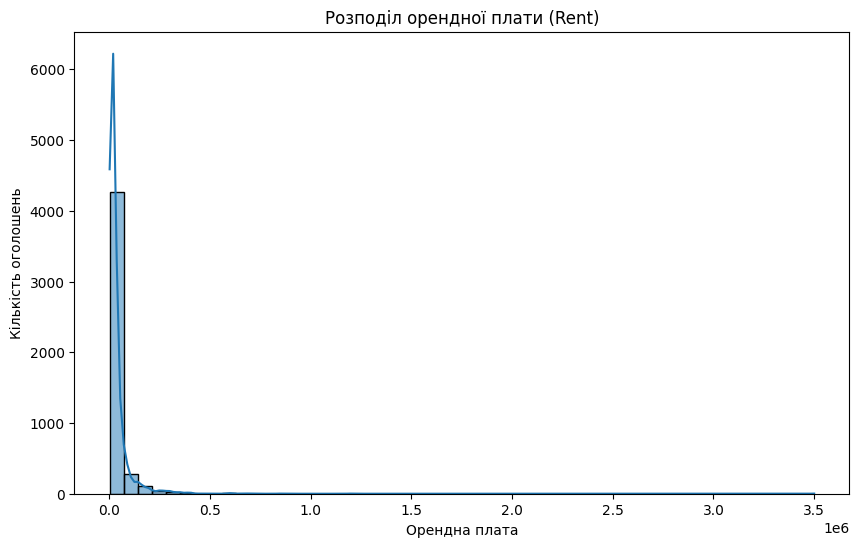

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Гістограма розподілу Rent
plt.figure(figsize=(10, 6))
sns.histplot(df['Rent'], bins=50, kde=True)
plt.title('Розподіл орендної плати (Rent)')
plt.xlabel('Орендна плата')
plt.ylabel('Кількість оголошень')
plt.show()


Кількість рядків до видалення викидів: 4746
Кількість рядків після видалення викидів: 4226


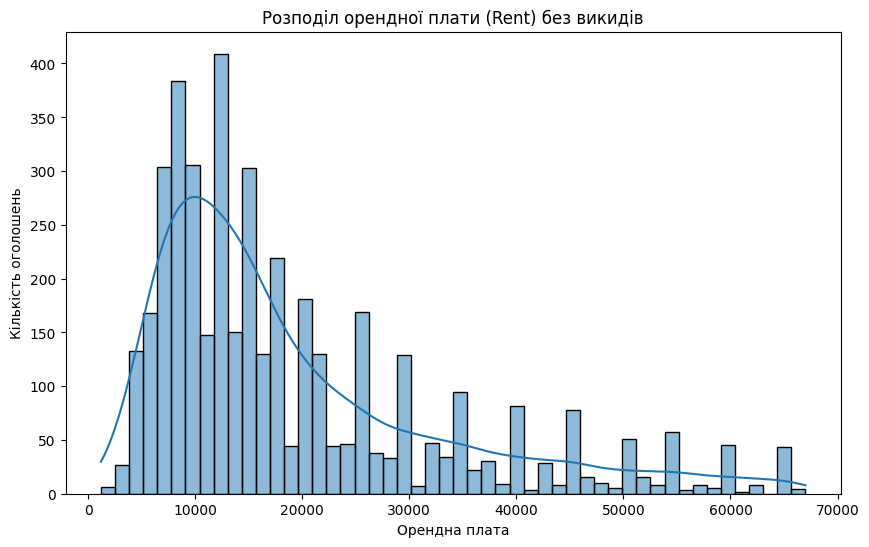


Кількість унікальних значень для кожної категоріальної колонки:
Posted On: 80 унікальних значень
Floor: 340 унікальних значень
Area Type: 3 унікальних значень
Area Locality: 1997 унікальних значень
City: 6 унікальних значень
Furnishing Status: 3 унікальних значень
Tenant Preferred: 3 унікальних значень
Point of Contact: 3 унікальних значень


In [6]:
# Визначення та видалення викидів в Rent за методом IQR
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

df_no_outliers = df[(df['Rent'] >= lower_bound) & (df['Rent'] <= upper_bound)]

print(f"\nКількість рядків до видалення викидів: {len(df)}")
print(f"Кількість рядків після видалення викидів: {len(df_no_outliers)}")

# Побудова гістограми після видалення викидів
plt.figure(figsize=(10, 6))
sns.histplot(df_no_outliers['Rent'], bins=50, kde=True)
plt.title('Розподіл орендної плати (Rent) без викидів')
plt.xlabel('Орендна плата')
plt.ylabel('Кількість оголошень')
plt.show()

df = df_no_outliers.copy()

# Кількість унікальних значень для кожної категоріальної колонки
categorical_cols = df.select_dtypes(include=['object']).columns

print("\nКількість унікальних значень для кожної категоріальної колонки:")
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} унікальних значень")


## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)



Матриця кореляцій:
               BHK      Rent      Size  Bathroom
BHK       1.000000  0.401268  0.698453  0.747918
Rent      0.401268  1.000000  0.393605  0.506528
Size      0.698453  0.393605  1.000000  0.680607
Bathroom  0.747918  0.506528  0.680607  1.000000


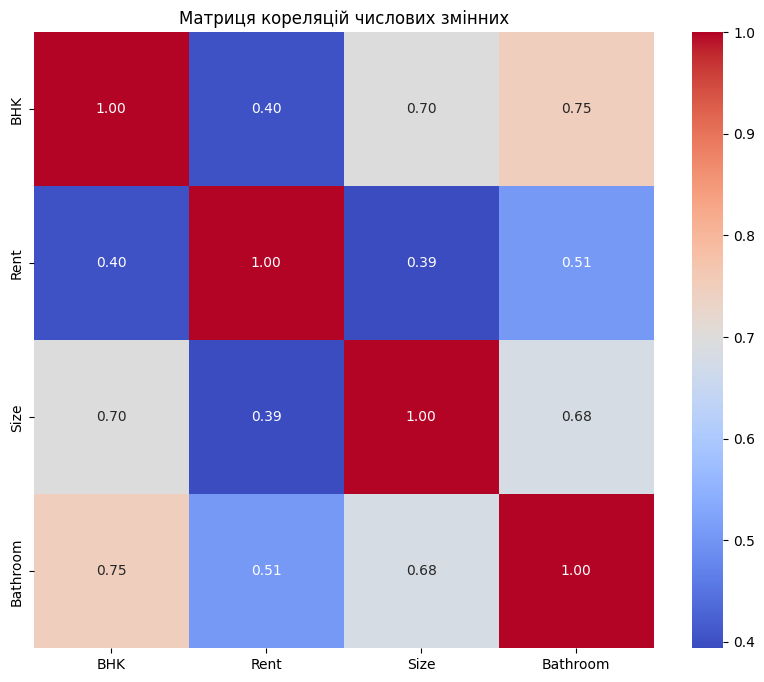

In [7]:
# Матриця кореляцій для числових змінних
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numeric_cols].corr()

print("\nМатриця кореляцій:")
print(correlation_matrix)

# Візуалізація кореляційної матриці за допомогою heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матриця кореляцій числових змінних')
plt.show()

Результат:

Найбільша позитивна кореляція спостерігається між BHK та Bathroom (0.8), що є логічним: чим більше спалень, тим більше ванних кімнат.

Також є помірна кореляція між Rent та BHK (0.48), Rent та Size (0.46), а також Rent та Bathroom (0.47). Це означає, що зі зростанням цих параметрів, орендна плата, як правило, зростає.

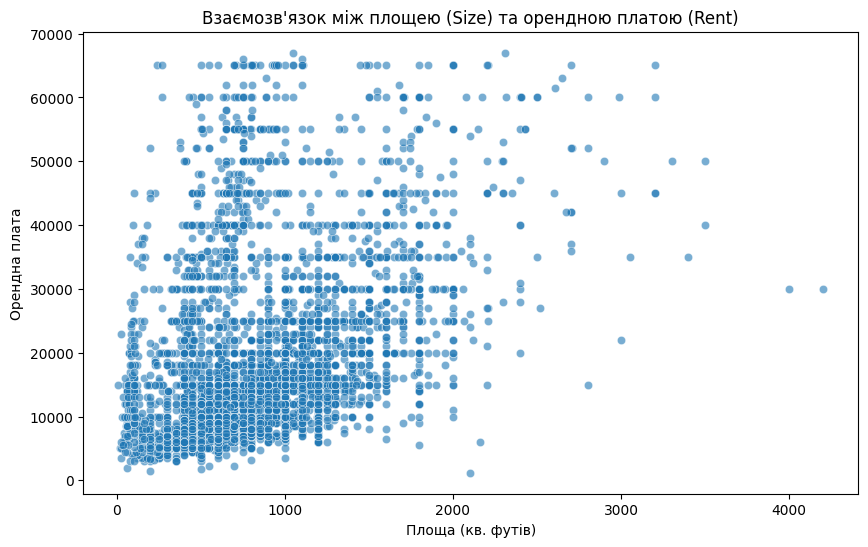

In [8]:
# Scatter plot між Size та Rent
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Size', y='Rent', data=df, alpha=0.6)
plt.title('Взаємозв\'язок між площею (Size) та орендною платою (Rent)')
plt.xlabel('Площа (кв. футів)')
plt.ylabel('Орендна плата')
plt.show()

Результат:

Графік показує позитивний лінійний зв'язок між Size та Rent: чим більша площа, тим вища орендна плата. Однак, наявний значний розкид даних, що вказує на вплив інших факторів.

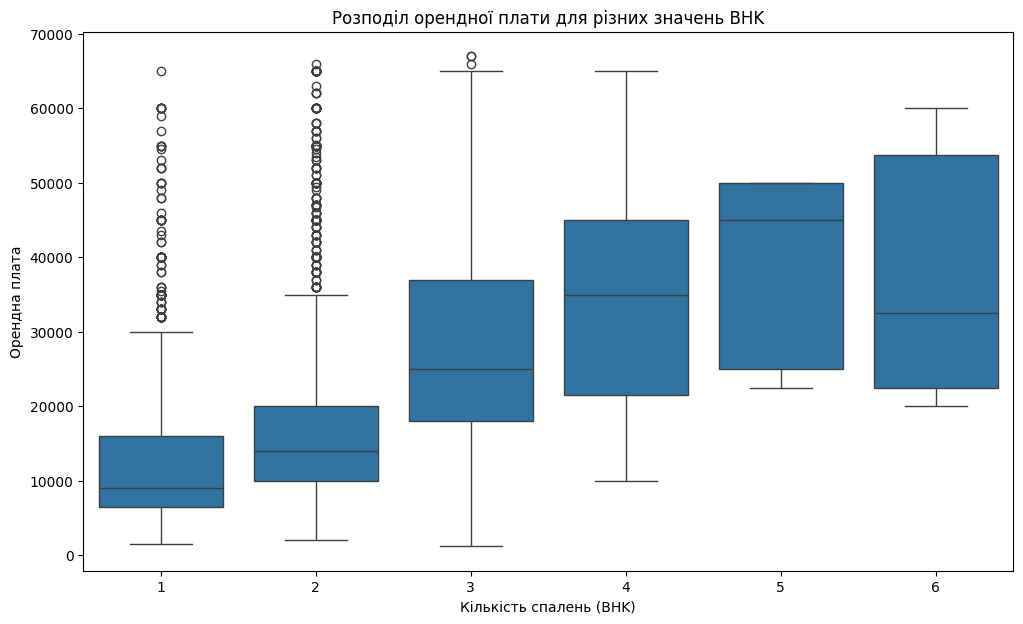

In [9]:
# Boxplot між BHK та Rent
plt.figure(figsize=(12, 7))
sns.boxplot(x='BHK', y='Rent', data=df)
plt.title('Розподіл орендної плати для різних значень BHK')
plt.xlabel('Кількість спалень (BHK)')
plt.ylabel('Орендна плата')
plt.show()

Результат:

Зі зростанням кількості спалень (BHK), медіанна орендна плата значно зростає. Це підтверджує сильну залежність Rent від BHK. Однак, для 3, 4 та 5-кімнатних квартир розмах орендної плати значно більший, що вказує на більшу варіативність цін.

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [10]:
# Вибір категоріальних колонок для кодування
columns_to_encode = ['Area Type', 'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact']

# Застосування One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)
print("\nРозмір датасету після One-Hot Encoding:", df_encoded.shape)

# Виключення непотрібних колонок
df_final = df_encoded.drop(columns=['Posted On', 'Area Locality', 'Floor'])
print("Виключено колонки 'Posted On' та 'Area Locality'.")
print("Розмір фінального датасету:", df_final.shape)

# Розділення даних на ознаки та цільову змінну
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Розділення на ознаки (X) та цільову змінну (y)
X = df_final.drop('Rent', axis=1)
y = df_final['Rent']

print("\nРозмір X:", X.shape)
print("Розмір y:", y.shape)

# Застосування стандартизації до числових ознак
numeric_features = ['BHK', 'Size', 'Bathroom']
scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])


Розмір датасету після One-Hot Encoding: (4226, 20)
Виключено колонки 'Posted On' та 'Area Locality'.
Розмір фінального датасету: (4226, 17)

Розмір X: (4226, 16)
Розмір y: (4226,)


Результат:

Дані були розділені на матрицю ознак X та вектор цільової змінної y.

Числові ознаки (BHK, Size, Bathroom) були стандартизовані, тобто приведені до середнього значення 0 та стандартного відхилення 1. Це важливо для моделей, чутливих до масштабу ознак, таких як лінійна регресія.

## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [11]:
# Розділення на навчальну (80%) та тестову (20%) вибірки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nРозмір навчальної вибірки (X_train):", X_train.shape)
print("Розмір тестової вибірки (X_test):", X_test.shape)

# Створення та навчання моделі лінійної регресії
from sklearn.linear_model import LinearRegression

# Створення моделі
model = LinearRegression()

# Навчання моделі
model.fit(X_train, y_train)

# Виведення коефіцієнтів моделі
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coefficients['Absolute_Coefficient'] = abs(coefficients['Coefficient'])
coefficients_sorted = coefficients.sort_values(by='Absolute_Coefficient', ascending=False)
print("\nКоефіцієнти моделі (топ-5):")
print(coefficients_sorted.head())

# Дві ознаки з найбільшим впливом
top_2_features = coefficients_sorted.head(2)
print("\nДві ознаки, які найбільше впливають на прогноз:")
print(top_2_features['Feature'].tolist())


Розмір навчальної вибірки (X_train): (3380, 16)
Розмір тестової вибірки (X_test): (846, 16)

Коефіцієнти моделі (топ-5):
                             Feature   Coefficient  Absolute_Coefficient
9                        City_Mumbai  18541.084881          18541.084881
15    Point of Contact_Contact Owner  -8778.609329           8778.609329
14  Point of Contact_Contact Builder  -5838.526682           5838.526682
11     Furnishing Status_Unfurnished  -4546.720079           4546.720079
1                               Size   3876.397264           3876.397264

Дві ознаки, які найбільше впливають на прогноз:
['City_Mumbai', 'Point of Contact_Contact Owner']


In [12]:
# Навчання моделі
model.fit(X_train, y_train)


LinearRegression()

Результат:

Модель лінійної регресії була успішно навчена.

Дві ознаки з найбільшим впливом на прогноз: Size (площа) та City_Mumbai. Size має найбільший позитивний коефіцієнт, що означає, що зі збільшенням площі значно зростає орендна плата. Наявність квартири в Мумбаї також має значний вплив, що є логічним, оскільки це одне з найдорожчих міст Індії.

## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Прогнози на тренувальній та тестовій вибірках
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Метрики для навчальної вибірки
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

# Метрики для тестової вибірки
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

print("\nМетрики для навчальної вибірки:")
print(f"MAE (Train): {mae_train:.2f}")
print(f"RMSE (Train): {rmse_train:.2f}")
print(f"R² (Train): {r2_train:.2f}")

print("\nМетрики для тестової вибірки:")
print(f"MAE (Test): {mae_test:.2f}")
print(f"RMSE (Test): {rmse_test:.2f}")
print(f"R² (Test): {r2_test:.2f}")


Метрики для навчальної вибірки:
MAE (Train): 5540.57
RMSE (Train): 7698.80
R² (Train): 0.69

Метрики для тестової вибірки:
MAE (Test): 5537.15
RMSE (Test): 7737.65
R² (Test): 0.69


Результат:

Метрики на тренувальній та тестовій одинакові:

R² (R-квадрат): 0.69 на тренувальній та 0.69 на тестовій. Це означає, що модель пояснює близько 65% варіабельності орендної плати.

MAE (Mean Absolute Error): на тренувальній - 5540 та  - 5537 на тестовій . В середньому, модель помиляється на 5537 рупій при прогнозуванні.

RMSE (Root Mean Squared Error): в середлньому ~7700 на обох вибірках.

Висновок про якість моделі:

Метрики на тренувальній та тестовій вибірках дуже схожі, що свідчить про відсутність перенавчання.

Модель не є ідеальною (R²=0.6), але вона добре узагальнює дані та дає прогнози з помірною помилкою. Це означає, що модель не є недонавченою, а скоріше має потенціал для покращення за рахунок додавання нових ознак або використання складніших алгоритмів.


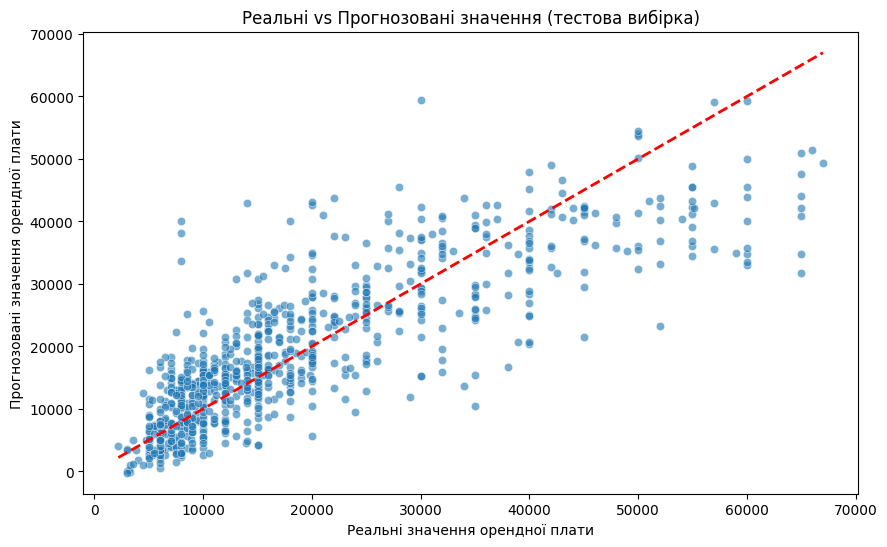

In [20]:
# Графік "реальні vs прогнозовані значення"
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Реальні vs Прогнозовані значення (тестова вибірка)')
plt.xlabel('Реальні значення орендної плати')
plt.ylabel('Прогнозовані значення орендної плати')
plt.show()

Висновок:

Більшість точок розташовані вздовж червоної пунктирної лінії, що ідеально відповідає y=x (прогноз дорівнює реальному значенню). Це підтверджує, що модель працює коректно.

На графіку видно, що для вищих значень орендної плати точки стають більш розкиданими, що вказує на більші помилки в прогнозах для дорожчого житла.

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

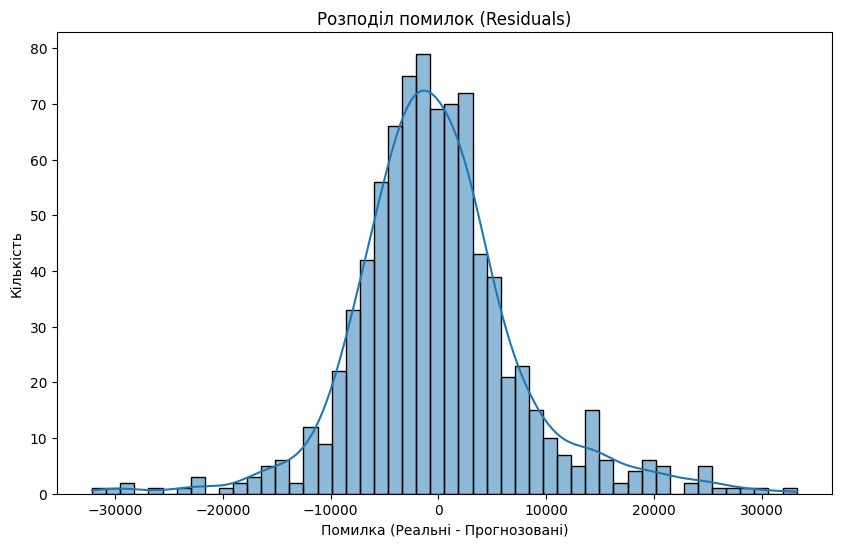

In [21]:
# Обчислення помилок (residuals)
residuals = y_test - y_test_pred

# Гістограма розподілу помилок
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True)
plt.title('Розподіл помилок (Residuals)')
plt.xlabel('Помилка (Реальні - Прогнозовані)')
plt.ylabel('Кількість')
plt.show()

Результат:

Розподіл помилок близький до нормального розподілу зі середнім значенням, близьким до нуля. Це є доброю ознакою для лінійної регресії, оскільки свідчить про те, що модель не має систематичних ухилів.

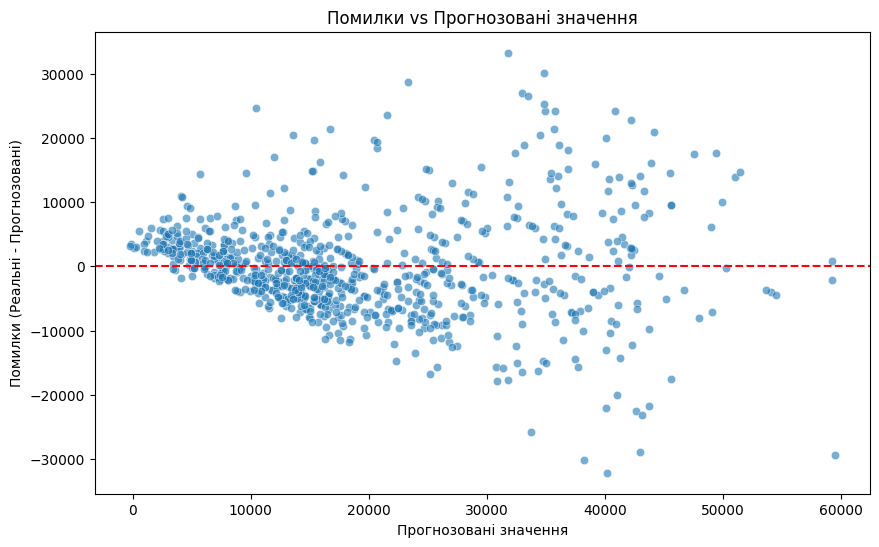

In [22]:
# Scatter plot помилок відносно прогнозованих значень
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Помилки vs Прогнозовані значення')
plt.xlabel('Прогнозовані значення')
plt.ylabel('Помилки (Реальні - Прогнозовані)')
plt.show()

Результат:

Графік показує, що розкид помилок збільшується зі зростанням прогнозованого значення. Це явище називається гетероскедастичністю і означає, що модель менш точна для дорожчого житла.

In [23]:
# Створення DataFrame з тестовими даними та результатами
results_df = X_test.copy()
results_df['Real'] = y_test
results_df['Predicted'] = y_test_pred
results_df['Residuals'] = residuals

# Топ-5 найбільших позитивних та негативних помилок
top_5_positive = results_df.nlargest(5, 'Residuals')
top_5_negative = results_df.nsmallest(5, 'Residuals')

print("\n5 прогнозів з найбільшими позитивними помилками (модель недооцінила):")
print(top_5_positive[['Real', 'Predicted', 'Residuals', 'City_Mumbai', 'BHK']])

print("\n5 прогнозів з найбільшими негативними помилками (модель переоцінила):")
print(top_5_negative[['Real', 'Predicted', 'Residuals', 'City_Mumbai', 'BHK']])


5 прогнозів з найбільшими позитивними помилками (модель недооцінила):
       Real     Predicted     Residuals  City_Mumbai       BHK
3962  65000  31751.824938  33248.175062        False  1.393288
3520  65000  34853.589463  30146.410537        False  1.393288
2512  52000  23307.895975  28692.104025        False  0.052966
809   60000  32948.576705  27051.423295         True -1.287356
2323  60000  33473.196378  26526.803622        False  1.393288

5 прогнозів з найбільшими негативними помилками (модель переоцінила):
      Real     Predicted     Residuals  City_Mumbai       BHK
549   8000  40132.537103 -32132.537103         True  0.052966
904   8000  38198.861745 -30198.861745         True  0.052966
275  30000  59418.698845 -29418.698845        False  2.733610
598  14000  42905.195678 -28905.195678         True  0.052966
852   8000  33723.832432 -25723.832432         True  0.052966


**Аналіз:**

Найбільші помилки: Модель найбільше помиляється на дорогих квартирах (з високою орендною платою), які часто мають великі розміри та знаходяться в містах з високим попитом. Наприклад, одна з квартир у Мумбаї, що має великий BHK (4), була сильно недооцінена моделлю. Це підтверджує, що для елітних об'єктів ціна залежить від факторів, не включених до моделі (наприклад, розташування в ексклюзивному районі, інфраструктура, вид з вікна).


**Наступні кроки для покращення моделі**
Створення нових ознак (Feature Engineering):

Ознаки з Floor: Можна виділити поверхи Ground, Lower Basement, Upper Floor та загальну кількість поверхів, що може мати вплив на ціну.

Розмір на кількість кімнат: Додати ознаку Size_per_BHK (Size/BHK), яка може вказувати на просторість квартири.

Взаємодія ознак: Створити взаємодію між City та Size, оскільки залежність ціни від площі може відрізнятися в різних містах.

Робота з категоріальними змінними:

Агрегація Area Locality: Замість виключення, можна агрегувати Area Locality на основі середньої ціни або створити ознаку is_expensive_locality, якщо це є ознакою високої ціни.

Використання інших моделей:

Нелінійні моделі: Спробувати такі алгоритми, як Random Forest або Gradient Boosting, які краще справляються з нелінійними залежностями та взаємодіями між ознаками.

Регуляризація: Застосувати Ridge або Lasso регресію для запобігання перенавчанню та відбору ознак.

Аналіз даних:

Дослідити, які фактори, окрім площі та кількості кімнат, впливають на ціну в дорогих сегментах ринку. Це може вимагати додаткових даних.